In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc

# UCI Machine Learning Repository üzerinden orijinal veri setinin canlı olarak çekilmesi
# Yerel dosya bağımlılıklarını ortadan kaldırmak ve kodun taşınabilirliğini artırmak amacıyla URL tanımı yapılmıştır
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ["variance", "skewness", "kurtosis", "entropy", "class"]
df = pd.read_csv(url, names=columns)

# Veri setinin başarılı bir şekilde yüklendiğinin doğrulanması ve ilk 5 satırının incelenmesi
print("Veri seti başarıyla yüklendi. İlk 5 gözlem:")
print(df.head())

Veri seti başarıyla yüklendi. İlk 5 gözlem:
   variance  skewness  kurtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


EDA BAŞLATILMIŞTIR


/tmp/ipykernel_951/2875809825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=df, palette='Set2')


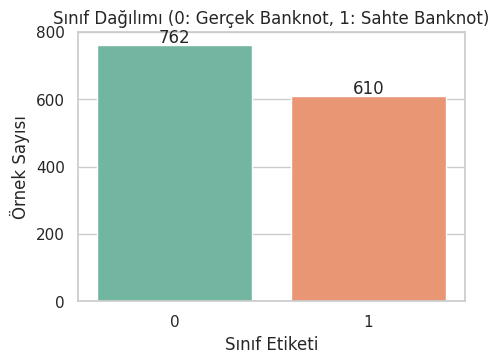

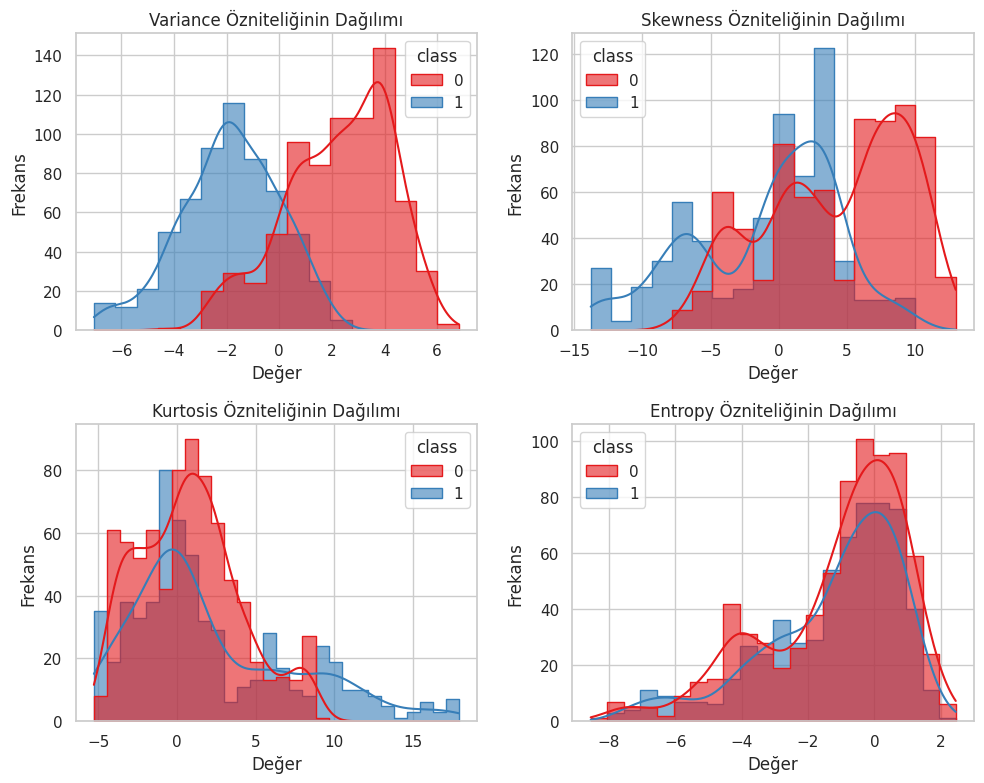

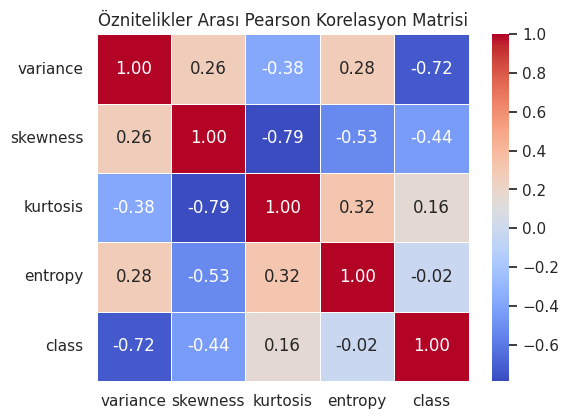

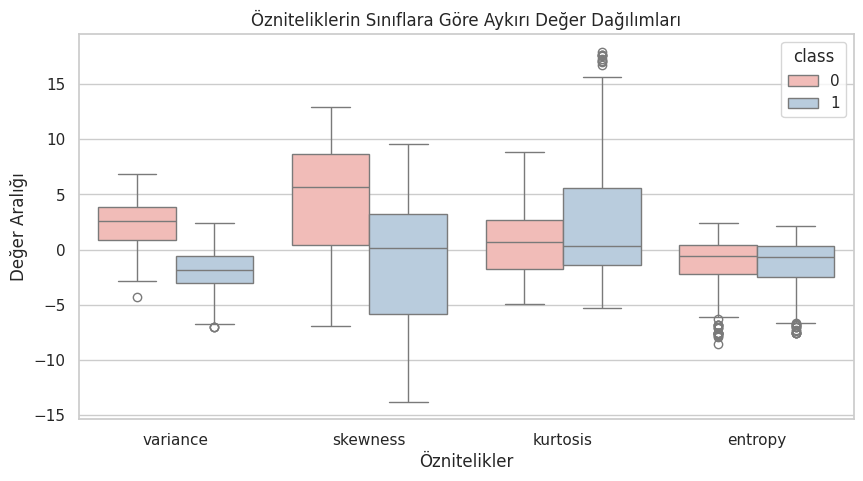

In [3]:
sns.set_theme(style="whitegrid")
print("EDA BAŞLATILMIŞTIR")

# A. Sınıf Dağılımının İncelenmesi (Class Distribution)
# Veri setindeki dengesizlik (imbalance) durumunu kontrol etmek amacıyla görselleştirme yapılmıştır
plt.figure(figsize=(5, 3.5))
ax = sns.countplot(x='class', data=df, palette='Set2')
plt.title('Sınıf Dağılımı (0: Gerçek Banknot, 1: Sahte Banknot)')
plt.xlabel('Sınıf Etiketi')
plt.ylabel('Örnek Sayısı')
# Sütunların üzerine net frekans değerlerinin yazdırılması
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# B. Öznitelik Dağılımları ve Yoğunluk Eğrileri (Histogram & KDE)
# Özniteliklerin sınıflara göre ayırt edicilik düzeylerini saptamak için histogramlar çizdirilmiştir
features = ["variance", "skewness", "kurtosis", "entropy"]
plt.figure(figsize=(10, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='class', kde=True, element='step', palette='Set1', alpha=0.6)
    plt.title(f'{col.capitalize()} Özniteliğinin Dağılımı')
    plt.xlabel('Değer')
    plt.ylabel('Frekans')
plt.tight_layout()
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# C. Öznitelikler Arası Korelasyon Analizi (Correlation Matrix)
# Değişkenlerin birbirleri ve hedef sınıf ile olan doğrusal ilişkilerini belirlemek amacıyla Pearson katsayıları hesaplanmıştır
plt.figure(figsize=(6, 4.5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Öznitelikler Arası Pearson Korelasyon Matrisi')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# D. Aykırı Değer Analizi (Outlier Analysis via Boxplot)
# Veri kümesindeki gürültüleri ve uç değerleri sınıflar bazında gözlemlemek adına kutu grafiği mimarisi kullanılmıştır
plt.figure(figsize=(10, 5))
df_melted = pd.melt(df, id_vars=['class'], value_vars=features, var_name='Ozellik', value_name='Deger')
sns.boxplot(x='Ozellik', y='Deger', hue='class', data=df_melted, palette='Pastel1')
plt.title('Özniteliklerin Sınıflara Göre Aykırı Değer Dağılımları')
plt.xlabel('Öznitelikler')
plt.ylabel('Değer Aralığı')
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Bağımsız değişkenlerin (X) ve hedef bağımlı değişkenin (y) matris formuna getirilmesi
X = df.drop('class', axis=1)
y = df['class']

# Hold-out yöntemi uygulanarak veri setinin %80'i eğitim, %20'si test verisi olacak şekilde ayrılmıştır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2000, random_state=42)

# Doğrusal karar sınırlarının performansını ölçmek amacıyla Linear Çekirdek (Linear Kernel) yapısına sahip SVM yapılandırılmıştır
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Eğitilen model üzerinden test veri setine ait sınıf tahminlerinin üretilmesi
y_pred = model.predict(X_test)

print("Eğitim ve bölme işlemleri başarıyla tamamlanmıştır.")

Eğitim ve bölme işlemleri başarıyla tamamlanmıştır.


MODEL PERFORMANS ÖLÇÜTLERİ
Accuracy (Doğruluk)    : %98.55
Precision (Kesinlik)   : %98.43
Sensitivity (Recall)   : %98.43
Specificity (Özgüllük) : %98.65
F1-Score               : %98.43
--------------------------------------------------


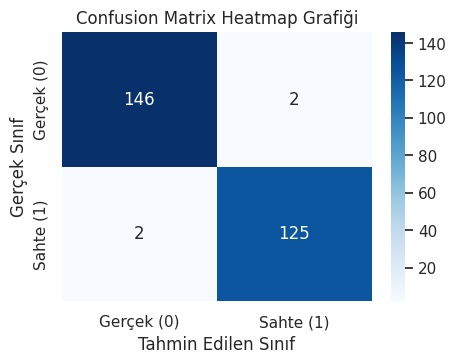

In [5]:
# Karışıklık Matrisi (Confusion Matrix) elemanlarının (TN, FP, FN, TP) elde edilmesi
from sklearn.metrics import confusion_matrix, precision_score
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Temel performans metriklerinin matematiksel formüllerle hesaplanması
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = precision_score(y_test, y_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print("MODEL PERFORMANS ÖLÇÜTLERİ")
print(f"Accuracy (Doğruluk)    : %{accuracy * 100:.2f}")
print(f"Precision (Kesinlik)   : %{precision * 100:.2f}")
print(f"Sensitivity (Recall)   : %{sensitivity * 100:.2f}")
print(f"Specificity (Özgüllük) : %{specificity * 100:.2f}")
print(f"F1-Score               : %{f1_score * 100:.2f}")
print("-" * 50)

# Confusion Matrix Heatmap Görselleştirmesi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Gerçek (0)', 'Sahte (1)'], yticklabels=['Gerçek (0)', 'Sahte (1)'])
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.title('Confusion Matrix Heatmap Grafiği')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

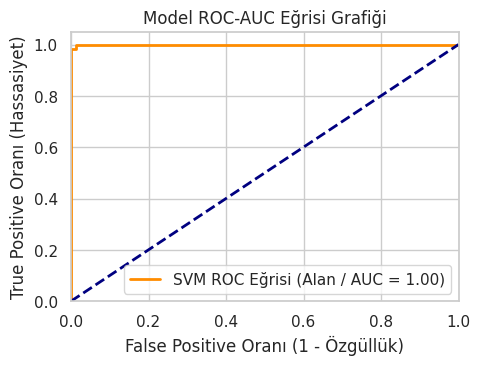

In [6]:
# Sınıflandırıcının ayırt edicilik gücünü eşik değerlerinden bağımsız ölçeklemek adına ROC analizi planlanmıştır
y_scores = model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# ROC Eğrisinin (Receiver Operating Characteristic) çizdirilmesi ve AUC değerinin hesaplanması
plt.figure(figsize=(5, 3.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM ROC Eğrisi (Alan / AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı (1 - Özgüllük)')
plt.ylabel('True Positive Oranı (Hassasiyet)')
plt.title('Model ROC-AUC Eğrisi Grafiği')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

ALTERNATİF SVM ÇEKİRDEK (KERNEL) ANALİZLERİ
SVM (LINEAR) Çekirdek Tipi Doğruluğu: %98.55
SVM (RBF) Çekirdek Tipi Doğruluğu: %100.00
SVM (POLY) Çekirdek Tipi Doğruluğu: %97.45
--------------------------------------------------


/tmp/ipykernel_951/2759032151.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=[k.upper() for k in kernel_listesi], y=dogruluk_skorlari, palette='muted')


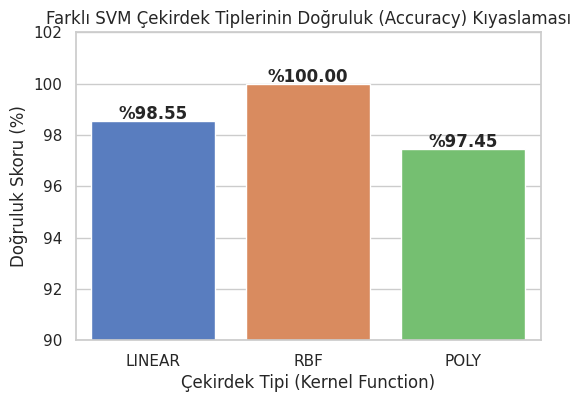

10-Fold Cross Validation Sonuçları:
[0.98550725 0.99275362 0.97080292 0.99270073 0.97080292 0.98540146
 1.         1.         0.99270073 0.98540146]

Ortalama Doğruluk: %98.76
Standart Sapma: %0.98


In [7]:
print("ALTERNATİF SVM ÇEKİRDEK (KERNEL) ANALİZLERİ")

kernel_listesi = ['linear', 'rbf', 'poly']
dogruluk_skorlari = []

# Farklı çekirdek modellerinin eğitilmesi ve doğruluk skorlarının toplanması
for kernel_tipi in kernel_listesi:
    gecici_model = SVC(kernel=kernel_tipi)
    gecici_model.fit(X_train, y_train)
    gecici_preds = gecici_model.predict(X_test)
    skor = accuracy_score(y_test, gecici_preds) * 100
    dogruluk_skorlari.append(skor)
    print(f"SVM ({kernel_tipi.upper()}) Çekirdek Tipi Doğruluğu: %{skor:.2f}")

print("-" * 50)

# Kernel başarılarının şık bir sütun grafiğiyle görselleştirilmesi
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=[k.upper() for k in kernel_listesi], y=dogruluk_skorlari, palette='muted')
plt.ylim(90, 102)  # Grafik farklarının net görünmesi için alt sınır set edilmiştir
plt.title('Farklı SVM Çekirdek Tiplerinin Doğruluk (Accuracy) Kıyaslaması')
plt.xlabel('Çekirdek Tipi (Kernel Function)')
plt.ylabel('Doğruluk Skoru (%)')

# Sütunların üzerine başarı yüzdelerinin eklenmesi
for p in ax.patches:
    ax.annotate(f'%{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.savefig('kernel_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Cross Validation (Model Doğrulama)

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=10
)

print("10-Fold Cross Validation Sonuçları:")
print(cv_scores)

print("\nOrtalama Doğruluk: %{:.2f}".format(cv_scores.mean() * 100))
print("Standart Sapma: %{:.2f}".format(cv_scores.std() * 100))